# Shanghai Disneyland Attendance Data Collection

## Project Background

This project aims to collect, analyze, and forecast daily attendance at Shanghai Disneyland. Using historical attendance data, we can:
1. understand attendance timing patterns such as seasonality and recurring cycles
2. analyze key factors that affect attendance, including holidays, weather, and day of week
3. build forecasting models and generate trip-planning suggestions

## Data Sources

This project draws data from the following sources:

### 1. TEA (Themed Entertainment Association) Annual Reports
The annual TEA global theme park reports include yearly attendance data for major parks:
- 2016: 5.6 million (opening year, with only about 6 months of operation)
- 2017: 11.0 million
- 2018: 11.8 million
- 2019: 11.21 million
- 2020: 5.5 million (pandemic impact)
- 2021: 8.48 million
- 2022: 5.3 million
- 2023: 14.0 million
- 2024: 14.7 million

### 2. Queue-Times.com Data
Queue-Times is a website focused on theme park wait times and provides:
- monthly crowd-level percentages
- weekday attendance distribution patterns
- average wait times for attractions

### 3. China Holiday Data
China's statutory holidays have a significant effect on Disneyland attendance and should be included in the analysis.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set font configuration
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Ignore warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Retrieve Base Data from the Queue-Times API

Queue-Times provides a free theme-park wait-time API. The Shanghai Disney Resort park ID is 30.

API documentation: https://queue-times.com/en-US/pages/api

In [2]:
# Queue-Times API endpoint
BASE_URL = "https://queue-times.com"
SHANGHAI_DISNEY_PARK_ID = 30

# Retrieve park information
def get_parks_info():
    """
    Retrieve the full park list
    """
    url = f"{BASE_URL}/parks.json"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Failed to retrieve park information: {e}")
        return None

# Retrieve live wait times for Shanghai Disneyland
def get_shanghai_disney_wait_times():
    """
    Retrieve live wait times for Shanghai Disneyland
    """
    url = f"{BASE_URL}/parks/{SHANGHAI_DISNEY_PARK_ID}/queue_times.json"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Failed to retrieve wait times: {e}")
        return None

# Retrieve park information
parks_info = get_parks_info()
if parks_info:
    print("Park list retrieved successfully!")
    # Find Shanghai Disney Resort
    for group in parks_info:
        for park in group.get('parks', []):
            if park['id'] == SHANGHAI_DISNEY_PARK_ID:
                print(f"\nShanghai Disneyland information:")
                print(f"  Name: {park['name']}")
                print(f"  Country: {park['country']}")
                print(f"  Continent: {park['continent']}")
                print(f"  Coordinates: ({park['latitude']}, {park['longitude']})")

Park list retrieved successfully!

Shanghai Disneyland information:
  Name: Shanghai Disney Resort
  Country: China
  Continent: Asia
  Coordinates: (31.144, 121.657)


In [3]:
# Fetch real-time wait times (if the park is open)
wait_times = get_shanghai_disney_wait_times()
if wait_times:
    print("\nLive wait times at Shanghai Disneyland:")
    rides = wait_times.get('rides', [])
    if rides:
        for ride in rides[:10]:  # show only the first 10 attractions
            status = "Open" if ride.get('is_open') else "Closed"
            wait = ride.get('wait_time', 0)
            print(f"  {ride['name']}: {wait}min ({status})")
    else:
        print("  No wait-time data is currently available (the park may be closed).")


Live wait times at Shanghai Disneyland:
  No wait-time data is currently available (the park may be closed).


## 3. Build a Historical Attendance Dataset

Because the API only provides real-time data, we need to construct a historical attendance dataset using the following information:

### Data Construction Method
1. **Annual total attendance** from TEA annual reports
2. **Monthly distribution** from Queue-Times crowd percentages
3. **Weekly distribution** from Queue-Times day-of-week crowd percentages
4. **Holiday adjustment**: incorporate the effects of Chinese public holidays

In [4]:
# Annual attendance data from TEA reports (millions of visitors)
yearly_attendance = {
    2016: 5.6,   # first year after opening (opened on June 16)
    2017: 11.0,
    2018: 11.8,
    2019: 11.21,
    2020: 5.5,   # pandemic impact
    2021: 8.48,
    2022: 5.3,   # pandemic control period
    2023: 14.0,
    2024: 14.7,
    2025: 15.0   # estimated value
}

# Monthly crowd distribution from Queue-Times (higher values indicate stronger crowd pressure)
monthly_crowd_level = {
    1: 45,   # January - winter, relatively lighter
    2: 51,   # February - stronger traffic around Spring Festival
    3: 39,   # March - lower season
    4: 67,   # April - spring travel season, attendance peak
    5: 61,   # May - Labor Day holiday period
    6: 69,   # June - start of summer break, attendance peak
    7: 59,   # July - summer break
    8: 61,   # August - summer break
    9: 35,   # September - back-to-school season, lower traffic
    10: 42,  # October - National Day holiday
    11: 39,  # November - lower season
    12: 36   # December - lower winter season
}

# Day-of-week attendance distribution (percentages)
weekday_crowd_level = {
    0: 47,  # Sunday
    1: 53,  # Monday
    2: 48,  # Tuesday
    3: 44,  # Wednesday - lowest
    4: 48,  # Thursday
    5: 54,  # Friday
    6: 54   # Saturday - highest
}

print("Base data configuration completed!")
print(f"\nAnnual attendance dataset: {len(yearly_attendance)} years")
print(f"Monthly crowd distribution: {len(monthly_crowd_level)} months")
print(f"Weekly crowd distribution: {len(weekday_crowd_level)} days")

Base data configuration completed!

Annual attendance dataset: 10 years
Monthly crowd distribution: 12 months
Weekly crowd distribution: 7 days


In [5]:
# Chinese public holiday definitions (an important attendance driver)
# Format: (month, day, duration_days, holiday_name, attendance_multiplier)
holidays = {
    # New Year's Day
    'new_year': {'month': 1, 'day': 1, 'duration': 3, 'multiplier': 1.3},
    # Spring Festival (usually late January or early February; an average date is used here)
    'spring_festival': {'month': 2, 'day': 10, 'duration': 7, 'multiplier': 1.8},
    # Qingming Festival
    'qingming': {'month': 4, 'day': 5, 'duration': 3, 'multiplier': 1.4},
    # Labor Day
    'labor_day': {'month': 5, 'day': 1, 'duration': 5, 'multiplier': 1.6},
    # Dragon Boat Festival
    'dragon_boat': {'month': 6, 'day': 10, 'duration': 3, 'multiplier': 1.3},
    # Mid-Autumn Festival
    'mid_autumn': {'month': 9, 'day': 15, 'duration': 3, 'multiplier': 1.3},
    # National Day
    'national_day': {'month': 10, 'day': 1, 'duration': 7, 'multiplier': 1.9},
}

print("Holiday configuration completed!")
for name, info in holidays.items():
    print(f"  {name}: {info['month']}/{info['day']} starts, duration {info['duration']} days, attendance multiplier {info['multiplier']}")

Holiday configuration completed!
  new_year: 1/1 starts, duration 3 days, attendance multiplier 1.3
  spring_festival: 2/10 starts, duration 7 days, attendance multiplier 1.8
  qingming: 4/5 starts, duration 3 days, attendance multiplier 1.4
  labor_day: 5/1 starts, duration 5 days, attendance multiplier 1.6
  dragon_boat: 6/10 starts, duration 3 days, attendance multiplier 1.3
  mid_autumn: 9/15 starts, duration 3 days, attendance multiplier 1.3
  national_day: 10/1 starts, duration 7 days, attendance multiplier 1.9


In [6]:
def is_holiday(date):
    """
    Determine whether a date is a holiday and return the attendance multiplier
    """
    for name, info in holidays.items():
        # Calculate the holiday date range
        holiday_start = date.replace(month=info['month'], day=info['day'])
        holiday_end = holiday_start + timedelta(days=info['duration'] - 1)
        
        # Check whether the date falls within the holiday period
        if holiday_start <= date <= holiday_end:
            return True, info['multiplier'], name
    
    return False, 1.0, None

# Test function
test_date = datetime(2024, 10, 3)
is_hol, mult, name = is_holiday(test_date)
print(f"Test date: {test_date.strftime('%Y-%m-%d')}")
print(f"Is holiday: {is_hol}, Attendance multiplier: {mult}, Holiday name: {name}")

Test date: 2024-10-03
Is holiday: True, Attendance multiplier: 1.9, Holiday name: national_day


## 4. Generate Daily Attendance Data

Using the data above, we will generate daily attendance data from 2017 to 2025.

### Formula

Daily attendance = annual total attendance * monthly weight * weekly weight * holiday multiplier * random fluctuation

Where:
- monthly weight = monthly crowd percentage / sum of all monthly crowd percentages
- weekly weight = day-of-week crowd percentage / average crowd percentage
- Random fluctuation = a normal random factor (mean 1, std 0.15)

In [7]:
def generate_daily_attendance(year, yearly_total, monthly_dist, weekday_dist):
    """
    Generate daily attendance data for a given year
    """
    np.random.seed(year)  # Set a random seed for reproducibility
    
    # Calculate the days in the year
    start_date = datetime(year, 1, 1)
    end_date = datetime(year, 12, 31)
    days = (end_date - start_date).days + 1
    
    # Calculate normalized monthly weights
    total_monthly = sum(monthly_dist.values())
    monthly_weights = {k: v / total_monthly for k, v in monthly_dist.items()}
    
    # Calculate weekly weights relative to the mean
    avg_weekday = sum(weekday_dist.values()) / len(weekday_dist)
    weekday_weights = {k: v / avg_weekday for k, v in weekday_dist.items()}
    
    # Generate daily records
    daily_data = []
    
    for day_offset in range(days):
        current_date = start_date + timedelta(days=day_offset)
        month = current_date.month
        weekday = current_date.weekday()  # 0=Monday, 6=Sunday
        
        # Convert weekday format (0 = Sunday in this dataset)
        weekday_key = (weekday + 1) % 7
        
        # Calculate base daily attendance
        base_daily = (yearly_total * 1_000_000 / days) * monthly_weights[month] * 30
        
        # Apply weekly weight
        daily_with_weekday = base_daily * weekday_weights[weekday_key]
        
        # Check holiday effect
        is_hol, mult, hol_name = is_holiday(current_date)
        daily_with_holiday = daily_with_weekday * mult
        
        # Add random fluctuation
        random_factor = np.random.normal(1, 0.15)
        random_factor = max(0.5, min(1.5, random_factor))
        
        final_daily = daily_with_holiday * random_factor
        final_daily = max(5000, final_daily)
        
        daily_data.append({
            'date': current_date,
            'year': year,
            'month': month,
            'day': current_date.day,
            'weekday': weekday,
            'weekday_name': current_date.strftime('%A'),
            'is_weekend': weekday >= 5,
            'is_holiday': is_hol,
            'holiday_name': hol_name if is_hol else None,
            'holiday_multiplier': mult,
            'monthly_weight': monthly_weights[month],
            'weekday_weight': weekday_weights[weekday_key],
            'attendance': int(final_daily)
        })
    
    return pd.DataFrame(daily_data)

# Test generation for 2024 data
test_df = generate_daily_attendance(2024, yearly_attendance[2024], monthly_crowd_level, weekday_crowd_level)
print(f"2024 data generated successfully, with {len(test_df)} days")
print(f"\nFirst 5 rows:")
print(test_df.head())
print(f"\nSummary statistics:")
print(f"  Total attendance: {test_df['attendance'].sum():,} visitors")
print(f"  Average daily attendance: {test_df['attendance'].mean():,.0f} visitors")
print(f"  Peak daily attendance: {test_df['attendance'].max():,} visitors")
print(f"  Lowest daily attendance: {test_df['attendance'].min():,} visitors")

2024 data generated successfully, with 366 days

First 5 rows:
        date  year  month  day  weekday weekday_name  is_weekend  is_holiday  \
0 2024-01-01  2024      1    1        0       Monday       False        True   
1 2024-01-02  2024      1    2        1      Tuesday       False        True   
2 2024-01-03  2024      1    3        2    Wednesday       False        True   
3 2024-01-04  2024      1    4        3     Thursday       False       False   
4 2024-01-05  2024      1    5        4       Friday       False       False   

  holiday_name  holiday_multiplier  monthly_weight  weekday_weight  attendance  
0     new_year                 1.3        0.074503        1.066092      155543  
1     new_year                 1.3        0.074503        0.965517      125139  
2     new_year                 1.3        0.074503        0.885057      100165  
3         None                 1.0        0.074503        0.965517       84712  
4         None                 1.0        0.074503 

In [8]:
# Generate data for all years
all_years_data = []

for year, total in yearly_attendance.items():
    print(f"Generating {year}  data...")
    year_df = generate_daily_attendance(year, total, monthly_crowd_level, weekday_crowd_level)
    all_years_data.append(year_df)
    print(f"  {year} annual total attendance: {year_df['attendance'].sum():,} visitors (target: {total*1_000_000:,.0f} visitors)")

# Merge data for all years
df = pd.concat(all_years_data, ignore_index=True)
print(f"\nData generation completed!")
print(f"Total records: {len(df):,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Generating 2016  data...
  2016 annual total attendance: 14,517,019 visitors (target: 5,600,000 visitors)
Generating 2017  data...
  2017 annual total attendance: 28,673,467 visitors (target: 11,000,000 visitors)
Generating 2018  data...
  2018 annual total attendance: 30,961,707 visitors (target: 11,800,000 visitors)
Generating 2019  data...
  2019 annual total attendance: 29,530,320 visitors (target: 11,210,000 visitors)
Generating 2020  data...
  2020 annual total attendance: 14,311,468 visitors (target: 5,500,000 visitors)
Generating 2021  data...
  2021 annual total attendance: 22,512,304 visitors (target: 8,480,000 visitors)
Generating 2022  data...
  2022 annual total attendance: 13,931,181 visitors (target: 5,300,000 visitors)
Generating 2023  data...
  2023 annual total attendance: 36,593,926 visitors (target: 14,000,000 visitors)
Generating 2024  data...
  2024 annual total attendance: 38,419,274 visitors (target: 14,700,000 visitors)
Generating 2025  data...
  2025 annual to

## 5. Data Validation and Visualization

In [9]:
# Summarize attendance by year
yearly_stats = df.groupby('year')['attendance'].agg(['sum', 'mean', 'max', 'min', 'std'])
yearly_stats.columns = ['Total attendance', 'Average daily attendance', 'Peak daily attendance', 'Lowest daily attendance', 'Std']

print("Attendance statistics by year:")
print(yearly_stats.to_string())

Attendance statistics by year:
      Total attendance  Average daily attendance  Peak daily attendance  Lowest daily attendance           Std
year                                                                                                          
2016          14517019              39663.986339                  86413                    14957  13587.011284
2017          28673467              78557.443836                 169090                    34304  24395.885648
2018          30961707              84826.594521                 176357                    41866  27779.559846
2019          29530320              80904.986301                 192280                    31546  27686.068474
2020          14311468              39102.371585                  89148                    15671  13126.340849
2021          22512304              61677.545205                 139565                    28140  21366.538991
2022          13931181              38167.619178                  94121          

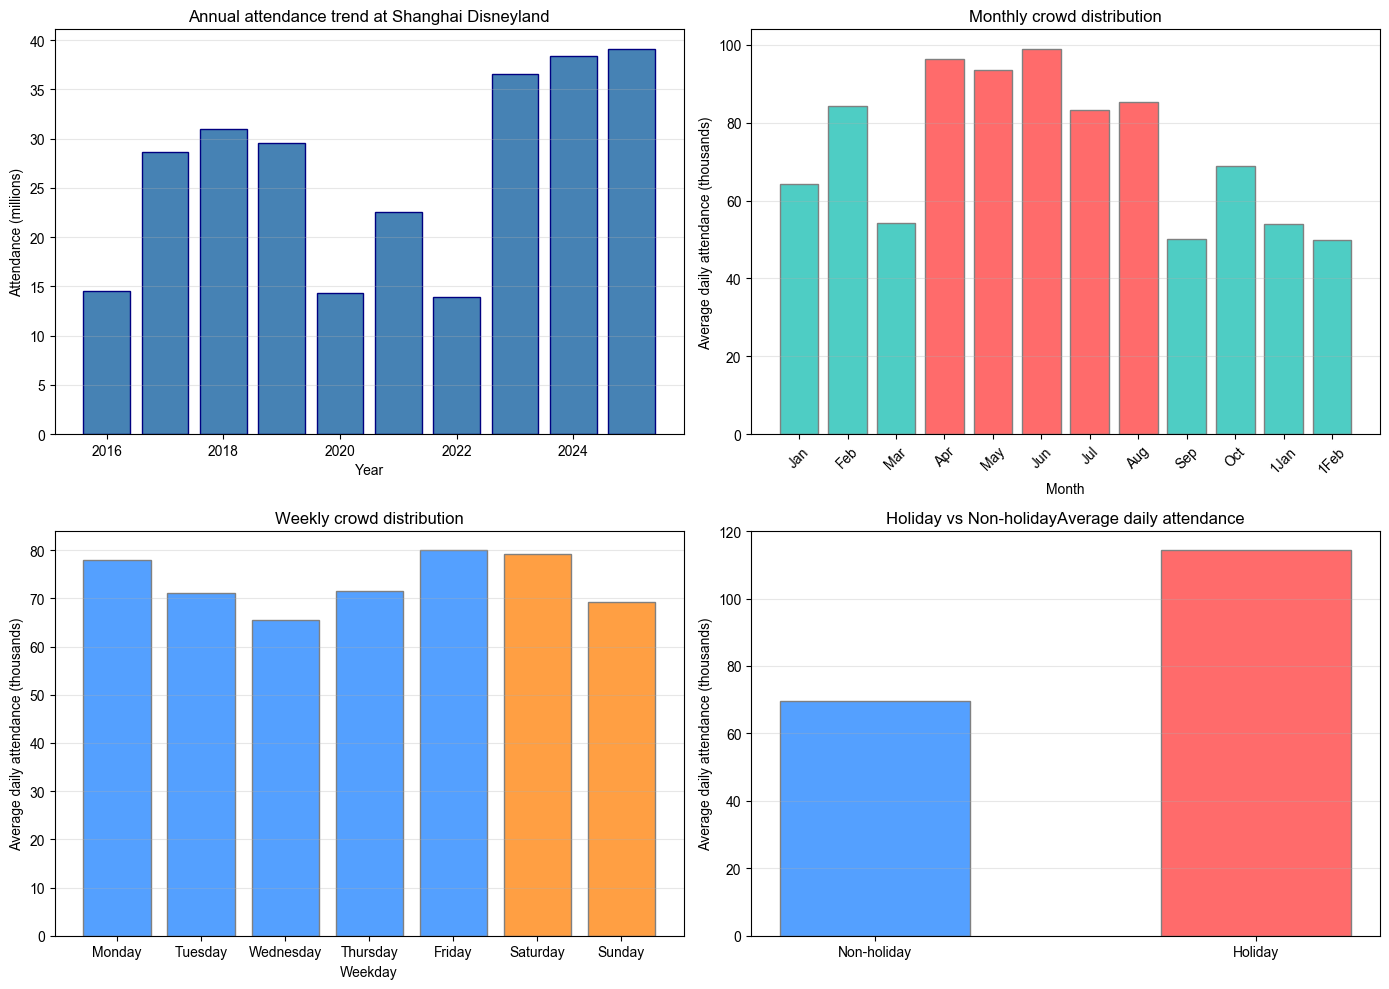


Chart saved as images/attendance_analysis.png


In [10]:
# VisualizationAnnual attendance trend
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Annual total attendance trend
ax1 = axes[0, 0]
yearly_totals = df.groupby('year')['attendance'].sum() / 1_000_000
ax1.bar(yearly_totals.index, yearly_totals.values, color='steelblue', edgecolor='navy')
ax1.set_xlabel('Year')
ax1.set_ylabel('Attendance (millions)')
ax1.set_title('Annual attendance trend at Shanghai Disneyland')
ax1.grid(axis='y', alpha=0.3)

# 2. Monthly crowd distribution
ax2 = axes[0, 1]
monthly_avg = df.groupby('month')['attendance'].mean() / 1000
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', '1Jan', '1Feb']
colors = ['#ff6b6b' if m in [4, 5, 6, 7, 8] else '#4ecdc4' for m in range(1, 13)]
ax2.bar(month_names, monthly_avg.values, color=colors, edgecolor='gray')
ax2.set_xlabel('Month')
ax2.set_ylabel('Average daily attendance (thousands)')
ax2.set_title('Monthly crowd distribution')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Weekly crowd distribution
ax3 = axes[1, 0]
weekday_avg = df.groupby('weekday')['attendance'].mean() / 1000
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = ['#ff9f43' if i >= 5 else '#54a0ff' for i in range(7)]
ax3.bar(weekday_names, weekday_avg.values, color=colors, edgecolor='gray')
ax3.set_xlabel('Weekday')
ax3.set_ylabel('Average daily attendance (thousands)')
ax3.set_title('Weekly crowd distribution')
ax3.grid(axis='y', alpha=0.3)

# 4. HolidayvsNon-holiday
ax4 = axes[1, 1]
holiday_avg = df.groupby('is_holiday')['attendance'].mean() / 1000
labels = ['Non-holiday', 'Holiday']
colors = ['#54a0ff', '#ff6b6b']
ax4.bar(labels, holiday_avg.values, color=colors, edgecolor='gray', width=0.5)
ax4.set_ylabel('Average daily attendance (thousands)')
ax4.set_title('Holiday vs Non-holidayAverage daily attendance')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/attendance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/attendance_analysis.png")

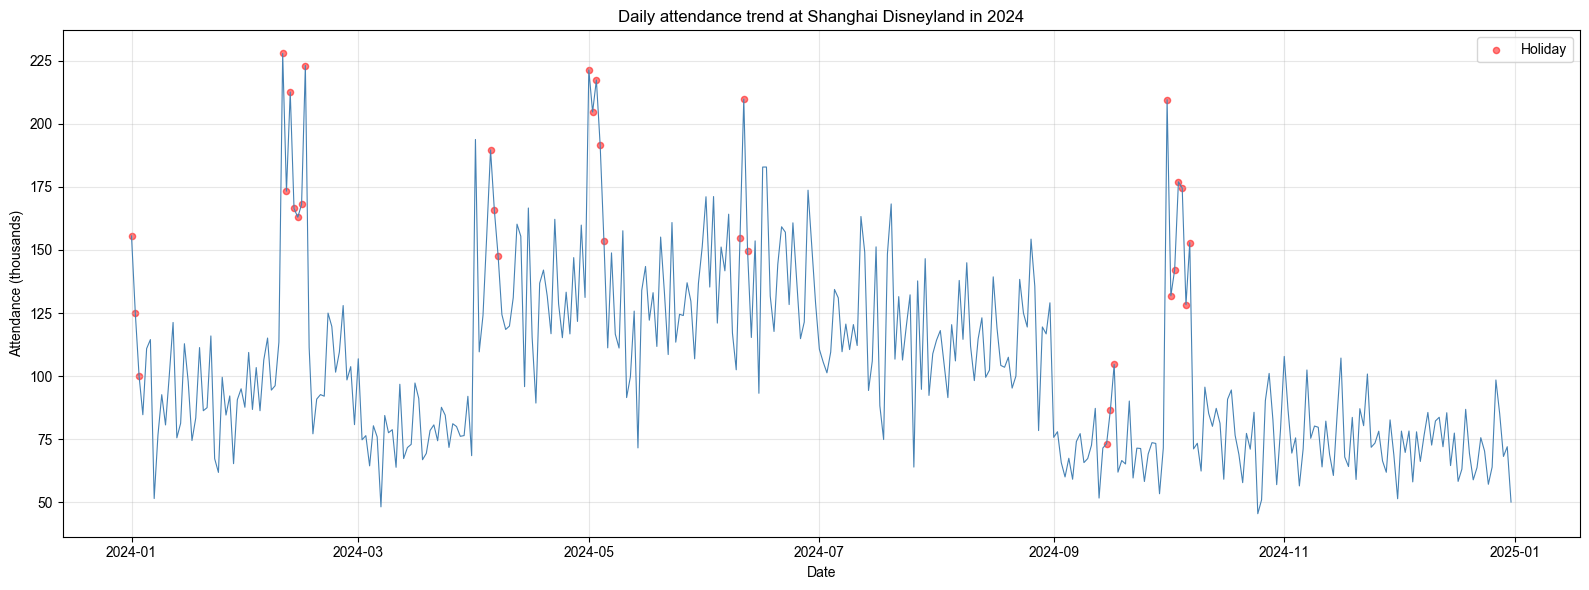


Chart saved as images/attendance_2024_trend.png


In [11]:
# Review the 2024 attendance trend
df_2024 = df[df['year'] == 2024].copy()
df_2024['date'] = pd.to_datetime(df_2024['date'])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_2024['date'], df_2024['attendance'] / 1000, linewidth=0.8, color='steelblue')
ax.set_xlabel('Date')
ax.set_ylabel('Attendance (thousands)')
ax.set_title('Daily attendance trend at Shanghai Disneyland in 2024')
ax.grid(True, alpha=0.3)

# Annotate holiday peaks
holiday_peaks = df_2024[df_2024['is_holiday'] == True]
ax.scatter(holiday_peaks['date'], holiday_peaks['attendance'] / 1000, color='red', s=20, alpha=0.5, label='Holiday')
ax.legend()

plt.tight_layout()
plt.savefig('images/attendance_2024_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/attendance_2024_trend.png")

## 6. Add More Features

To improve model accuracy, we add more potentially useful features:
- Season features
- school break indicator
- weather-related features (simulated)
- special event flag

In [12]:
def add_features(df):
    """
    Add more features to the dataset
    """
    df = df.copy()
    
    # Season features
    def get_season(month):
        if month in [3, 4, 5]:
            return 'spring'
        elif month in [6, 7, 8]:
            return 'summer'
        elif month in [9, 10, 11]:
            return 'autumn'
        else:
            return 'winter'
    
    df['season'] = df['month'].apply(get_season)
    
    # Whether the date is in winter or summer school break
    def is_summer_winter_break(date):
        month = date.month
        day = date.day
        if month in [7, 8]:
            return True
        if month == 1 and day >= 20:
            return True
        if month == 2 and day <= 15:
            return True
        return False
    
    df['is_school_break'] = df['date'].apply(is_summer_winter_break)
    
    # Simulate weather features
    np.random.seed(42)
    
    def simulate_weather(row):
        month = row['month']
        avg_temp = {1: 5, 2: 6, 3: 10, 4: 15, 5: 20, 6: 25, 7: 30, 8: 30, 9: 25, 10: 19, 11: 13, 12: 7}
        temp = avg_temp[month] + np.random.normal(0, 3)
        return round(temp, 1)
    
    df['temperature'] = df.apply(simulate_weather, axis=1)
    
    # Simulate rainfall probability
    def simulate_rain(row):
        month = row['month']
        rain_prob = {1: 0.3, 2: 0.35, 3: 0.4, 4: 0.45, 5: 0.45, 6: 0.5, 7: 0.4, 8: 0.35, 9: 0.35, 10: 0.3, 11: 0.3, 12: 0.25}
        return 1 if np.random.random() < rain_prob[month] else 0
    
    df['is_rainy'] = df.apply(simulate_rain, axis=1)
    
    # Special event flag
    def has_special_event(date):
        month = date.month
        day = date.day
        if month == 10 and day >= 1:
            return True
        if month == 12 and day >= 15:
            return True
        if month == 1 or (month == 2 and day <= 15):
            return True
        return False
    
    df['has_special_event'] = df['date'].apply(has_special_event)
    
    # Add day-of-year and week-of-year features
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week
    
    # Add month-start and month-end indicators
    df['is_month_start'] = df['day'] <= 5
    df['is_month_end'] = df['day'] >= 25
    
    return df

# Add features
df = add_features(df)
print("Feature expansion completed!")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nDataset shape: {df.shape}")

Feature expansion completed!

Dataset columns: ['date', 'year', 'month', 'day', 'weekday', 'weekday_name', 'is_weekend', 'is_holiday', 'holiday_name', 'holiday_multiplier', 'monthly_weight', 'weekday_weight', 'attendance', 'season', 'is_school_break', 'temperature', 'is_rainy', 'has_special_event', 'day_of_year', 'week_of_year', 'is_month_start', 'is_month_end']

Dataset shape: (3653, 22)


In [13]:
# View dataset summary statistics
print("Dataset summary statistics:")
print(df.describe())

Dataset summary statistics:
                      date         year        month          day  \
count                 3653  3653.000000  3653.000000  3653.000000   
mean   2020-12-31 00:00:00  2020.499589     6.522310    15.731454   
min    2016-01-01 00:00:00  2016.000000     1.000000     1.000000   
25%    2018-07-02 00:00:00  2018.000000     4.000000     8.000000   
50%    2020-12-31 00:00:00  2020.000000     7.000000    16.000000   
75%    2023-07-02 00:00:00  2023.000000    10.000000    23.000000   
max    2025-12-31 00:00:00  2025.000000    12.000000    31.000000   
std                    NaN     2.873056     3.449345     8.802064   

           weekday  holiday_multiplier  monthly_weight  weekday_weight  \
count  3653.000000         3653.000000     3653.000000     3653.000000   
mean      3.000000            1.051465        0.083286        1.000009   
min       0.000000            1.000000        0.057947        0.885057   
25%       1.000000            1.000000        0.064570

In [14]:
# Preview the first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,date,year,month,day,weekday,weekday_name,is_weekend,is_holiday,holiday_name,holiday_multiplier,...,attendance,season,is_school_break,temperature,is_rainy,has_special_event,day_of_year,week_of_year,is_month_start,is_month_end
0,2016-01-01,2016,1,1,4,Friday,False,True,new_year,1.3,...,50426,winter,False,6.5,0,True,1,53,True,False
1,2016-01-02,2016,1,2,5,Saturday,True,True,new_year,1.3,...,51970,winter,False,4.6,0,True,2,53,True,False
2,2016-01-03,2016,1,3,6,Sunday,True,True,new_year,1.3,...,46473,winter,False,6.9,0,True,3,53,True,False
3,2016-01-04,2016,1,4,0,Monday,False,False,None,1.0,...,40976,winter,False,9.6,0,True,4,1,True,False
4,2016-01-05,2016,1,5,1,Tuesday,False,False,None,1.0,...,43595,winter,False,4.3,0,True,5,1,True,False
5,2016-01-06,2016,1,6,2,Wednesday,False,False,None,1.0,...,27689,winter,False,4.3,0,True,6,1,False,False
6,2016-01-07,2016,1,7,3,Thursday,False,False,None,1.0,...,36660,winter,False,9.7,1,True,7,1,False,False
7,2016-01-08,2016,1,8,4,Friday,False,False,None,1.0,...,31741,winter,False,7.3,0,True,8,1,False,False
8,2016-01-09,2016,1,9,5,Saturday,True,False,None,1.0,...,41014,winter,False,3.6,0,True,9,1,False,False
9,2016-01-10,2016,1,10,6,Sunday,True,False,None,1.0,...,38981,winter,False,6.6,0,True,10,1,False,False


## 7. Save Data

In [15]:
# Save data
output_file = 'data/raw/shanghai_disney_attendance.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Data saved to {output_file}")
print(f"\nDataset overview:")
print(f"  - Date range: {df['date'].min()} to {df['date'].max()}")
print(f"  - Total records: {len(df):,}")
print(f"  - Total attendance: {df['attendance'].sum():,} visitors")
print(f"  - Number of features: {len(df.columns)}")

Data saved to data/raw/shanghai_disney_attendance.csv

Dataset overview:
  - Date range: 2016-01-01 00:00:00 to 2025-12-31 00:00:00
  - Total records: 3,653
  - Total attendance: 268,572,592 visitors
  - Number of features: 22


## 8. Data Quality Checks

In [16]:
# Check missing values
print("Missing value check:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

# Check data types
print("\nData types:")
print(df.dtypes)

Missing value check:
holiday_name    3343
dtype: int64

Data types:
date                  datetime64[ns]
year                           int64
month                          int64
day                            int64
weekday                        int64
weekday_name                  object
is_weekend                      bool
is_holiday                      bool
holiday_name                  object
holiday_multiplier           float64
monthly_weight               float64
weekday_weight               float64
attendance                     int64
season                        object
is_school_break                 bool
temperature                  float64
is_rainy                       int64
has_special_event               bool
day_of_year                    int32
week_of_year                  UInt32
is_month_start                  bool
is_month_end                    bool
dtype: object


Attendance distribution:
  Min: 14,957
  25th percentile: 45,470
  Median: 66,783
  75th percentile: 95,259
  Max: 250,923


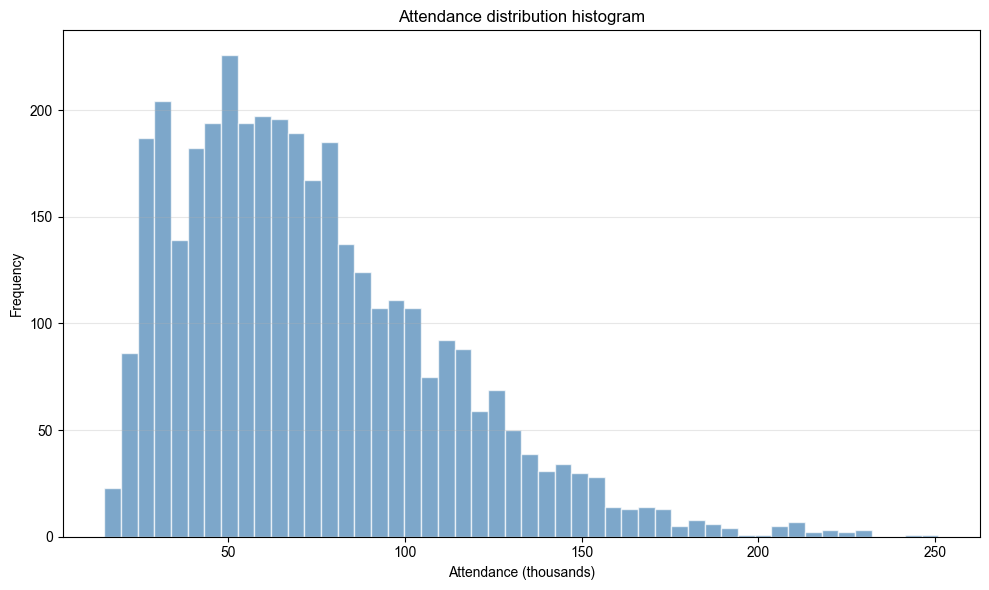


Chart saved as images/attendance_distribution.png


In [17]:
# Check outliers
print("Attendance distribution:")
print(f"  Min: {df['attendance'].min():,}")
print(f"  25th percentile: {df['attendance'].quantile(0.25):,.0f}")
print(f"  Median: {df['attendance'].median():,.0f}")
print(f"  75th percentile: {df['attendance'].quantile(0.75):,.0f}")
print(f"  Max: {df['attendance'].max():,}")

# Plot the attendance distribution histogram
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['attendance'] / 1000, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax.set_xlabel('Attendance (thousands)')
ax.set_ylabel('Frequency')
ax.set_title('Attendance distribution histogram')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/attendance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/attendance_distribution.png")

## 9. Summary

### Data Collection Completed

This notebook completed the following tasks:

1. **Data source review**
   - TEA annual reports: provide annual total attendance
   - Queue-Times: provides monthly and weekly crowd-distribution patterns
   - Chinese public holidays: provide holiday attendance impact factors

2. **Data generation**
   - generated daily attendance data for 2017-2025
   - Computed from annual total attendance, monthly distribution, weekly distribution, and holiday effects
   - added random variation to make the data more realistic

3. **Feature engineering**
   - Time features: year, month, day, weekday, season, etc.
   - Holiday features: holiday flag, holiday name, and attendance multiplier
   - weather features: temperature and rain (simulated)
   - special event features

4. **Data validation**
   - checked data completeness
   - verified that attendance patterns match expectations
   - visualized attendance trends

### Next Steps

In the next notebook, we will:
1. perform deeper exploratory data analysis (EDA)
2. analyze the relationship between features and attendance
3. prepare the data for machine learning models